# SABR Paper Reproduction Walkthrough - Fast Presentation Demo

This notebook mirrors `paper_reproduction_walkthrough.ipynb` section by section, but uses smaller Monte Carlo budgets so it can be rerun live during a presentation.

Paper:
- Choi, Hu, Kwok, *Efficient and accurate simulation of the stochastic-alpha-beta-rho model*

Project scope preserved from the full walkthrough:
- core SABR Monte Carlo simulator
- sanity checks for limiting cases and martingale behavior
- paper-style tables and figure datasets
- quick and paper-scale validation hooks

Important: the live-demo cells below are intentionally noisier than the full paper-scale reproduction because `n_paths` and `n_repeats` are reduced. The algorithms, parameter cases, and helper functions are unchanged.


## Guided Paper Introduction

This opening section is a compact English version of the project intro. It follows the paper's logic step by step before we run the code.

### Stop 1: What is the SABR model?

The SABR model describes the joint movement of a forward price and its stochastic volatility:

$$
dF_t = \sigma_t F_t^\beta dW_t,
\qquad
\frac{d\sigma_t}{\sigma_t} = \nu dZ_t,
\qquad
dW_t dZ_t = \rho dt.
$$

In plain language:

| Symbol | Meaning |
|---|---|
| $F_t$ | Forward price, the quantity we simulate and price options on. |
| $\sigma_t$ | Stochastic volatility, itself random over time. |
| $\beta$ | Elasticity parameter: closer to 1 means lognormal-like, closer to 0 means normal-like. |
| $\nu$ | Vol-of-vol: how violently volatility itself moves. |
| $\rho$ | Correlation between price and volatility shocks. |

A key convenience is that volatility is easy to simulate exactly:

$$
\sigma_{t+h}=\sigma_t\exp\left(\nu\sqrt{h}X-\frac12\nu^2h\right),
\qquad X\sim N(0,1).
$$

So the hard part is not the volatility step. The hard part is how to simulate the next forward price accurately and fast.

### Stop 2: The two-step simulation framework

Once $\sigma_{t+h}$ is known, SABR simulation methods usually split the remaining problem into two conditional tasks:

<div style="display:flex; align-items:center; gap:10px; flex-wrap:wrap; margin:12px 0;">
  <div style="border:1px solid #888; border-radius:6px; padding:10px; background:#f7f7f7; width:210px;"><b>Known at time t</b><br><code>F_t, sigma_t</code></div>
  <div style="font-size:24px;">-&gt;</div>
  <div style="border:1px solid #888; border-radius:6px; padding:10px; background:#f7f7f7; width:220px;"><b>Exact volatility step</b><br>sample <code>sigma_{t+h}</code></div>
  <div style="font-size:24px;">-&gt;</div>
  <div style="border:1px solid #888; border-radius:6px; padding:10px; background:#f7f7f7; width:230px;"><b>Step 1</b><br>sample average variance <code>I_t^h</code></div>
  <div style="font-size:24px;">-&gt;</div>
  <div style="border:1px solid #888; border-radius:6px; padding:10px; background:#f7f7f7; width:230px;"><b>Step 2</b><br>sample next forward <code>F_{t+h}</code></div>
</div>

The normalized average variance is

$$
I_t^h = \frac{1}{\sigma_t^2 h}\int_t^{t+h}\sigma_s^2ds\;\Bigg|\;\sigma_{t+h}.
$$

Intuitively, $I_t^h$ measures how much volatility was accumulated during the step. It is scaled so that when vol-of-vol is zero, $I_t^h=1$.

### Stop 3: Special cases that explain the target

Before the general case, the paper reviews special cases where the conditional forward distribution is easier:

| Case | Why it helps |
|---|---|
| $\beta=0$ normal SABR | Conditional forward is normal, but the price can become negative. |
| $\beta=1$ lognormal SABR | Conditional forward is lognormal with an explicit conditional mean. |
| $\nu=0$ zero vol-of-vol | SABR reduces to the CEV model. |
| $\rho=0$ zero correlation | Conditional forward also has a CEV form. |

These cases reveal the central design goal: a good general SABR simulator should be fast, accurate, nonnegative for $0<\beta<1$, and should preserve the martingale condition

$$
\mathbb{E}[F_T]\approx F_0.
$$


## The Paper's Main Algorithmic Ideas

### Stop 4: Step 1 samples average variance with a shifted lognormal distribution

The paper approximates $I_t^h$ with a shifted-lognormal random variable:

$$
I_t^h \approx \mu\left[\frac16 + \frac56\exp\left(aX-\frac12a^2\right)\right],
\qquad X\sim N(0,1).
$$

The mean and variance inputs come from exact conditional moment formulas. The shift weight $5/6$ comes from the small-time limit.

Why this matters:

| Method idea | Tradeoff |
|---|---|
| Plain lognormal approximation | Fast, but only matches fewer moments. |
| Inverse transform / Fourier methods | More exact, but slow and implementation-heavy. |
| Paper's shifted lognormal | Still fast, but matches the distribution shape much better. |

This is Algorithm 1. Figure 1 later checks that the shifted-lognormal approximation tracks skewness and excess kurtosis well.

### Stop 5: Step 2 uses a martingale-preserving CEV approximation

The paper's main innovation is the conditional forward approximation. In the general correlated case, the exact conditional law of $F_{t+h}$ is not available. The paper approximates it as a CEV distribution:

$$
F_{t+h}\mid \sigma_{t+h}, I_t^h
\approx
\mathrm{CEV}_{\beta}\left(\bar F_t^h, (\rho^*)^2\sigma_t^2hI_t^h\right).
$$

The crucial object is $\bar F_t^h$, the conditional mean parameter. It is constructed so that the CEV approximation preserves the forward martingale property as much as possible.

This is the key difference from Islah's approximation. Islah's method is widely used, but it can break the martingale property, so forward-price drift accumulates over long maturities. Figure 3 later demonstrates this directly.

### Stop 6: CEV can be sampled exactly and quickly

A CEV transition is connected to a noncentral chi-square distribution. The paper uses a Gamma-Poisson-Gamma construction to sample it without root-finding.

<div style="display:flex; align-items:center; gap:10px; flex-wrap:wrap; margin:12px 0;">
  <div style="border:1px solid #888; border-radius:6px; padding:10px; background:#f7f7f7; width:185px;"><b>Gamma draw</b><br>test absorption at zero</div>
  <div style="font-size:24px;">-&gt;</div>
  <div style="border:1px solid #888; border-radius:6px; padding:10px; background:#f7f7f7; width:185px;"><b>Poisson draw</b><br>mixture index</div>
  <div style="font-size:24px;">-&gt;</div>
  <div style="border:1px solid #888; border-radius:6px; padding:10px; background:#f7f7f7; width:185px;"><b>Gamma draw</b><br>terminal CEV state</div>
  <div style="font-size:24px;">-&gt;</div>
  <div style="border:1px solid #888; border-radius:6px; padding:10px; background:#f7f7f7; width:185px;"><b>Transform back</b><br>obtain <code>F_{t+h}</code></div>
</div>

This is Algorithm 3. It is fast because it uses standard random variables and avoids iterative inversion.

### Stop 7: Algorithm 4 puts everything together

For each time step:

1. Sample $\sigma_{t+h}$ exactly.
2. Sample $I_t^h$ with the shifted-lognormal approximation.
3. Compute the martingale-preserving CEV mean $\bar F_t^h$.
4. Sample $F_{t+h}$ from the CEV distribution exactly.
5. Repeat until maturity.

The overall method is efficient because every step uses direct random sampling, not PDE solves, matrix operations, or inverse CDF root-finding.


## How the Numerical Sections Fit the Story

### Stop 8: What the paper's tables and figures are trying to prove

| Result | Purpose in the paper | Where we run it |
|---|---|---|
| Table 1 | Isolate the error from the shifted-lognormal average-variance approximation in the $\beta=1$ case. | Section 6 |
| Table 2 | Separate error sources across $\rho=1$, $0.75$, and $0$, and across different $\beta$ and $\nu$. | Section 7 |
| Figure 1 | Show that shifted lognormal captures higher moments of $I_t^h$ better than plain lognormal. | Section 8 |
| Tables 4-5 | Test long-maturity Case I and II option prices against FDM and analytic approximation rows. | Sections 9-10 |
| Table 6 | Compare Case III against other Monte Carlo baseline rows from the paper. | Section 11 |
| Table 7 / Figure 2 | Show the runtime versus RMS-error tradeoff. | Section 12 |
| Figure 3 | Compare the paper method against Islah and show the martingale advantage. | Section 13 |

For the live presentation, we keep the same functions, cases, and section order, but reduce path counts and repeats. That makes the notebook runnable on stage while preserving the paper's logic.


## Contents

0. [Guided Paper Introduction](#Guided-Paper-Introduction)
0. [The Paper's Main Algorithmic Ideas](#The-Paper's-Main-Algorithmic-Ideas)
0. [How the Numerical Sections Fit the Story](#How-the-Numerical-Sections-Fit-the-Story)
1. [Environment and Imports](#1.-Environment-and-Imports)
2. [Project API Overview](#2.-Project-API-Overview)
3. [Core Mathematical Formulas](#3.-Core-Mathematical-Formulas)
4. [Table 3 Cases](#4.-Table-3-Cases)
5. [Sanity Checks](#5.-Sanity-Checks)
6. [Paper Table 1](#6.-Paper-Table-1)
7. [Paper Table 2](#7.-Paper-Table-2)
8. [Paper Figure 1 Dataset](#8.-Paper-Figure-1-Dataset)
9. [Paper Table 4](#9.-Paper-Table-4)
10. [Paper Table 5](#10.-Paper-Table-5)
11. [Paper Table 6](#11.-Paper-Table-6)
12. [Paper Table 7 / Figure 2](#12.-Paper-Table-7-/-Figure-2)
13. [Paper Figure 3](#13.-Paper-Figure-3)
14. [Validation Summary](#14.-Validation-Summary)
15. [Optional CSV Export Helpers](#15.-Optional-CSV-Export-Helpers)


## 1. Environment and Imports

Run this first. It checks the working directory, imports the project module, and shows package versions when available.


In [23]:
from pathlib import Path
import sys
import platform
import importlib
import time

import numpy as np
import pandas as pd

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print('Python:', sys.version)
print('Platform:', platform.platform())
print('Project root:', PROJECT_ROOT)

for pkg in ['numpy', 'pandas', 'scipy', 'pyfeng', 'pytest']:
    mod = importlib.import_module(pkg)
    print(f'{pkg}:', getattr(mod, '__version__', 'version unavailable'))


DEMO_N_PATHS_SMALL = 3_000
DEMO_N_PATHS_TABLE = 5_000
DEMO_REPEATS_SMALL = 2
DEMO_REPEATS_TABLE = 2
DEMO_TABLE7_BASE_PATHS = 5_000
DEMO_TABLE7_BENCHMARK_PATHS = 10_000
DEMO_FIGURE3_PATHS = 3_000
DEMO_FIGURE3_BENCHMARK_PATHS = 6_000

runtime_rows = []
notebook_start = time.perf_counter()

def timed(label, fn):
    start = time.perf_counter()
    value = fn()
    elapsed = time.perf_counter() - start
    runtime_rows.append({'section': label, 'seconds': elapsed})
    print(f'{label}: {elapsed:.2f} sec')
    return value

print('Fast demo mode: smaller Monte Carlo budgets for live presentation')
print('Table demos:', DEMO_N_PATHS_TABLE, 'paths x', DEMO_REPEATS_TABLE, 'repeats')


Python: 3.10.18 | packaged by Anaconda, Inc. | (main, Jun  5 2025, 13:08:55) [MSC v.1929 64 bit (AMD64)]
Platform: Windows-10-10.0.26200-SP0
Project root: c:\Users\zhyim\Desktop\quant\Numeric Method\numerical-project-main\numerical-project-main\numerical-project-main
numpy: 2.2.6
pandas: 2.2.3
scipy: 1.15.3
pyfeng: version unavailable
pytest: 9.0.3
Fast demo mode: smaller Monte Carlo budgets for live presentation
Table demos: 5000 paths x 2 repeats


In [24]:
from sabr_replicate import (
    FDMConfig,
    MonteCarloConfig,
    SABRParams,
    case_table_3,
    conditional_integrated_variance_moments,
    european_call_price,
    fdm_benchmark_prices,
    figure1_moment_comparison,
    figure2_runtime_tradeoff,
    finite_difference_call_price,
    martingale_test,
    raw_moments_to_central_stats,
    run_figure3_experiment,
    run_full_validation,
    run_table1_experiment,
    run_table2_experiment,
    run_table4_experiment,
    run_table5_experiment,
    run_table6_experiment,
    run_table7_experiment,
    sample_conditional_integrated_variance,
    simulate_terminal_forward,
    simulate_terminal_forward_islah,
)
import pyfeng as pf


## 2. Project API Overview

This section is only for orientation. It lists the main functions used later in the notebook.


## 3. Core Mathematical Formulas


Presentation note: the guided introduction above is designed to be enough for the live talk. This formula section is kept as a reference page so the fast demo still mirrors the original walkthrough.
This section collects the formulas that the implementation is reproducing. In the code, the same objects appear as `SABRParams`, `MonteCarloConfig`, `sample_conditional_integrated_variance`, `sample_cev_exact`, and `simulate_terminal_forward`.

### 3.1 SABR model

The SABR dynamics are

$$
dF_t = \sigma_t F_t^\beta\, dW_t,
\qquad
\frac{d\sigma_t}{\sigma_t} = \nu\, dZ_t,
\qquad
dW_t\,dZ_t = \rho\,dt .
$$

The exact volatility step over one interval of length $h$ is

$$
\sigma_{t+h}
=
\sigma_t
\exp\left(\nu\sqrt{h}X_\sigma - \frac{1}{2}\nu^2 h\right),
\qquad X_\sigma \sim N(0,1).
$$

We use

$$
\hat\nu = \nu\sqrt{h},
\qquad
\beta^* = 1-\beta,
\qquad
\rho^* = \sqrt{1-\rho^2}.
$$

### 3.2 Algorithm 1: conditional average variance

After sampling $\sigma_{t+h}$, the first hard quantity is the normalized conditional average variance

$$
I_t^h
=
\frac{1}{\sigma_t^2 h}
\int_t^{t+h} \sigma_s^2\,ds
\;\Bigg|\;\sigma_{t+h}.
$$

Let

$$
\mu = \mathbb{E}\left[I_t^h \mid \sigma_{t+h}\right],
\qquad
v =
\frac{
\sqrt{\mathrm{Var}\left(I_t^h \mid \sigma_{t+h}\right)}
}{
\mathbb{E}\left[I_t^h \mid \sigma_{t+h}\right]
}.
$$

With fixed shift

$$
\lambda = \frac{5}{6},
$$

the lognormal shape parameter is

$$
a
=
\sqrt{\log\left(1 + \frac{v^2}{\lambda^2}\right)}
=
\sqrt{\log\left(1 + \frac{36}{25}v^2\right)}.
$$

Algorithm 1 samples

$$
I_t^h
\approx
\mu
\left[
\frac{1}{6}
+
\frac{5}{6}
\exp\left(aX - \frac{1}{2}a^2\right)
\right],
\qquad X\sim N(0,1).
$$

In the implementation, `conditional_integrated_variance_moments` supplies the moments and `sample_conditional_integrated_variance` performs this shifted-lognormal sampling.

### 3.3 Algorithm 2: martingale-preserving CEV approximation

For $0<\beta<1$, conditional on $\sigma_{t+h}$ and $I_t^h$,

$$
F_{t+h}\mid \sigma_{t+h}, I_t^h
\approx
\mathrm{CEV}_\beta\left(\bar F_t^h, (\rho^*)^2\sigma_t^2 h I_t^h\right).
$$

The conditional mean is

$$
\bar F_t^h
\approx
F_t
\exp\left(
\frac{\rho(\sigma_{t+h}-\sigma_t)}{\nu F_t^{\beta^*}}
-
\frac{\rho^2\sigma_t^2 h I_t^h}{2F_t^{2\beta^*}}
\right).
$$

This construction is meant to preserve the martingale condition:

$$
\mathbb{E}[F_{t+h}\mid \sigma_{t+h}, I_t^h] = \bar F_t^h,
\qquad
\mathbb{E}[F_{t+h}] = F_t.
$$

For the lognormal special case $\beta=1$,

$$
F_{t+h}
=
\bar F_t^h
\exp\left(
\rho^*\sigma_t\sqrt{hI_t^h}X
-
\frac{1}{2}(\rho^*)^2\sigma_t^2 hI_t^h
\right),
\qquad X\sim N(0,1).
$$

### 3.4 Algorithm 3: exact CEV sampling

For
$$
F_T \sim \mathrm{CEV}_\beta(F_0, \sigma_0^2T),
$$

define
$$
\alpha = \frac{1}{2\beta^*},
\qquad
z_0 = \frac{F_0^{2\beta^*}}{(\beta^*)^2\sigma_0^2T}.
$$

Sample
$$
X \sim \Gamma(\alpha,1),
$$
where $\Gamma(\alpha,1)$ denotes a Gamma distribution with shape $\alpha$ and unit scale.

If $X \ge z_0/2$, set $F_T = 0$ (absorbing boundary). Otherwise sample
$$
N \sim \mathrm{Poisson}(z_0/2 - X),
\qquad
z_T \sim 2\Gamma(N+1,1),
$$

and return
$$
F_T = \left((\beta^*)^2\sigma_0^2Tz_T\right)^{1/(2\beta^*)}.
$$

This provides an exact sampling scheme for the CEV distribution via a Poisson–Gamma mixture representation.

Inside SABR, this sampler is applied with
$$
F_0 \leftarrow \bar F_t^h,
\qquad
\sigma_0^2T \leftarrow (\rho^*)^2\sigma_t^2hI_t^h.
$$

### 3.5 Algorithm 4: full simulation over a time grid

For each time step:

1. Sample $\sigma_{t+h}$ exactly.
2. Sample $I_t^h$ using Algorithm 1.
3. Compute $\bar F_t^h$ using Algorithm 2.
4. Sample $F_{t+h}$ using Algorithm 3.
5. Repeat until maturity $T$.

The Monte Carlo European call estimator is

$$
\widehat C(K)
=
\frac{1}{N}\sum_{i=1}^N \max(F_T^{(i)}-K,0).
$$

The reported errors are

$$
\text{bias} = \widehat C - C_{\text{benchmark}},
\qquad
\text{relative error} = \frac{\widehat C-C_{\text{benchmark}}}{C_{\text{benchmark}}},
$$

$$
\text{RMS error} = \sqrt{\text{bias}^2 + \text{stdev}^2}.
$$

The martingale check verifies numerically that

$$
\mathbb{E}[F_T] = F_0.
$$

Presentation note: these formulas correspond directly to Algorithms 1-4. The implementation uses the same objects through `sample_conditional_integrated_variance`, `sample_cev_exact`, and `simulate_terminal_forward`.


In [25]:
api_overview = pd.DataFrame(
    [
        ('simulate_terminal_forward', 'Main SABR Monte Carlo terminal simulator using the paper scheme'),
        ('simulate_terminal_forward_islah', 'Appendix B / Islah-style comparison branch'),
        ('sample_conditional_integrated_variance', 'Algorithm 1 style conditional average-variance sampling'),
        ('conditional_integrated_variance_moments', 'Conditional raw moments of normalized average variance'),
        ('run_table1_experiment', 'Paper Table 1 dataset'),
        ('run_table2_experiment', 'Paper Table 2 dataset'),
        ('run_table4_experiment', 'Paper Table 4 dataset'),
        ('run_table5_experiment', 'Paper Table 5 dataset'),
        ('run_table6_experiment', 'Paper Table 6 dataset'),
        ('run_table7_experiment', 'Paper Table 7 / Figure 2 dataset'),
        ('run_figure3_experiment', 'Paper Figure 3 dataset'),
        ('run_full_validation', 'Repository validation harness'),
    ],
    columns=['function', 'purpose'],
)
api_overview


,function,purpose
0,simulate_terminal_forward,Main SABR Monte Carlo terminal simulator using...
1,simulate_terminal_forward_islah,Appendix B / Islah-style comparison branch
2,sample_conditional_integrated_variance,Algorithm 1 style conditional average-variance...
3,conditional_integrated_variance_moments,Conditional raw moments of normalized average ...
4,run_table1_experiment,Paper Table 1 dataset
5,run_table2_experiment,Paper Table 2 dataset
6,run_table4_experiment,Paper Table 4 dataset
7,run_table5_experiment,Paper Table 5 dataset
8,run_table6_experiment,Paper Table 6 dataset
9,run_table7_experiment,Paper Table 7 / Figure 2 dataset


## 4. Paper parameter presets

These are the paper parameter presets used throughout later sections.


In [26]:
case_df = pd.DataFrame(case_table_3()).T
case_df.index.name = 'case'
case_df


,f0,sigma0,nu,rho,beta,maturity
case,,,,,,
Case I,1.00,0.25,0.3,-0.8,0.3,10.0
Case II,1.00,0.25,0.3,-0.5,0.6,10.0
Case III,0.05,0.40,0.6,0.0,0.3,1.0
Case IV,1.10,0.40,0.8,-0.3,0.3,4.0
Case V,1.10,0.30,0.5,-0.8,0.4,10.0


## 5. Sanity Checks

These cells verify model-level behavior that should hold independently of the paper tables.

Purpose: before reproducing paper tables, these cells verify that the simulator behaves correctly in limiting cases where independent reference prices or structural properties are available. These checks are kept in full in the fast demo.


### 5.1 `nu = 0` should reduce SABR to CEV

This isolates the zero vol-of-vol limit. SABR becomes a CEV model, so Monte Carlo call prices can be checked against PyFeng CEV prices.


In [27]:
params = SABRParams(f0=1.0, sigma0=0.25, nu=0.0, rho=-0.4, beta=0.3)
mc = MonteCarloConfig(maturity=1.0, step=1.0, n_paths=200_000, seed=12345)
strikes = np.array([0.6, 1.0, 1.4])

terminal = simulate_terminal_forward(params, mc)
mc_prices = np.array([european_call_price(terminal, k) for k in strikes])
cev_prices = pf.Cev(sigma=params.sigma0, beta=params.beta, is_fwd=True).price(strikes, params.f0, mc.maturity)

pd.DataFrame({
    'strike': strikes,
    'mc_price': mc_prices,
    'cev_price': cev_prices,
    'error': mc_prices - cev_prices,
})


,strike,mc_price,cev_price,error
0,0.6,0.404583,0.404036,0.000547
1,1.0,0.099984,0.099602,0.000382
2,1.4,0.007369,0.007385,-0.000016


### 5.2 `beta = 1, nu = 0` should reduce SABR to Black-Scholes / lognormal

This checks the lognormal limit. With constant volatility and `beta=1`, the SABR simulator should reproduce Black-Scholes forward call prices.


In [28]:
params = SABRParams(f0=1.0, sigma0=0.2, nu=0.0, rho=-0.75, beta=1.0)
mc = MonteCarloConfig(maturity=1.0, step=1.0, n_paths=200_000, seed=12345)
strikes = np.array([0.8, 1.0, 1.2])

terminal = simulate_terminal_forward(params, mc)
mc_prices = np.array([european_call_price(terminal, k) for k in strikes])
bsm_prices = pf.Bsm(sigma=params.sigma0, is_fwd=True).price(strikes, params.f0, mc.maturity)

pd.DataFrame({
    'strike': strikes,
    'mc_price': mc_prices,
    'bsm_price': bsm_prices,
    'error': mc_prices - bsm_prices,
})


,strike,mc_price,bsm_price,error
0,0.8,0.212078,0.211859,0.000219
1,1.0,0.079613,0.079656,-0.000043
2,1.2,0.021431,0.021473,-0.000042


### 5.3 Conditional average-variance moment spot check

This is a small diagnostic cell for the `I_t^h` machinery used inside the full simulator.

This inspects the moment inputs used by Algorithm 1. The shifted-lognormal sampler is only as good as the conditional moment calculations it is fitted to.


In [29]:
sigma_t = np.array([0.2])
sigma_next = np.array([0.24])
nu = 0.4
h = 1.0

mu1, mu2_raw, mu3_raw, mu4_raw = conditional_integrated_variance_moments(sigma_t, sigma_next, nu, h)
mean, var, std, cv, skewness, ex_kurtosis = raw_moments_to_central_stats(mu1, mu2_raw, mu3_raw, mu4_raw)

pd.DataFrame({
    'mu1': mu1,
    'mu2_raw': mu2_raw,
    'mu3_raw': mu3_raw,
    'mu4_raw': mu4_raw,
    'var': var,
    'std': std,
    'cv': cv,
    'skewness': skewness,
    'ex_kurtosis': ex_kurtosis,
})


,mu1,mu2_raw,mu3_raw,mu4_raw,var,std,cv,skewness,ex_kurtosis
0,1.272973,1.712454,2.438791,3.683759,0.091994,0.303305,0.238265,0.884234,1.467284


### 5.4 Martingale sanity check

The forward price should remain close to a martingale: sample means should stay near `F0` up to Monte Carlo noise. This is central to the paper.


In [30]:
case_v = case_table_3()['Case V']
params = SABRParams(
    f0=case_v['f0'],
    sigma0=case_v['sigma0'],
    nu=case_v['nu'],
    rho=case_v['rho'],
    beta=case_v['beta'],
)

martingale_test(params, maturities=[1, 2, 4, 6, 8, 10], step=1.0, n_paths=30_000, seed0=101)


,maturity,mean_terminal,std_terminal,stderr_terminal,martingale_error,z_score,runtime_sec,step,n_paths,conclusion
0,1.0,1.098478,0.305621,0.001765,-0.001522,-0.862636,0.021139,1.0,30000,Monte Carlo noise dominated
1,2.0,1.102482,0.422185,0.002437,0.002482,1.018128,0.019988,1.0,30000,Monte Carlo noise dominated
2,4.0,1.107439,0.563293,0.003252,0.007439,2.287301,0.038822,1.0,30000,Monte Carlo noise dominated
3,6.0,1.105598,0.643586,0.003716,0.005598,1.506589,0.056838,1.0,30000,Monte Carlo noise dominated
4,8.0,1.101523,0.703496,0.004062,0.001523,0.374890,0.072894,1.0,30000,Monte Carlo noise dominated
5,10.0,1.099555,0.741081,0.004279,-0.000445,-0.103937,0.089891,1.0,30000,Monte Carlo noise dominated


### 5.5 `|rho| = 1` Islah edge case stability

This is a numerical robustness check for the comparison branch. At full correlation, some generic Islah formulas have removable singularities.


In [31]:
rows = []
for beta in (0.4, 0.6, 0.8):
    params = SABRParams(f0=1.0, sigma0=0.2, nu=0.2, rho=1.0, beta=beta)
    mc = MonteCarloConfig(maturity=1.0, step=1.0, n_paths=5_000, seed=123)
    terminal = simulate_terminal_forward_islah(params, mc)
    rows.append({
        'beta': beta,
        'all_finite': bool(np.isfinite(terminal).all()),
        'all_nonnegative': bool((terminal >= 0.0).all()),
        'mean_terminal': float(np.mean(terminal)),
        'min_terminal': float(np.min(terminal)),
    })

pd.DataFrame(rows)


,beta,all_finite,all_nonnegative,mean_terminal,min_terminal
0,0.4,True,True,1.009120,0.536459
1,0.6,True,True,1.013306,0.558478
2,0.8,True,True,1.017677,0.577711


## 6. Paper Table 1

By default, this uses the paper table benchmarks embedded in the repo. To compare against the repo PDE benchmark instead, run the later FDM cells or pass benchmark providers in standalone scripts.


Fast demo note: this calls the same Table 1 helper as the full walkthrough, but with smaller `n_paths` and `n_repeats` for live execution.

Purpose: isolate the error from Algorithm 1 in the lognormal SABR case (`beta=1`), where the conditional forward step is analytically simpler.


In [32]:
table1_df = timed(
    'Paper Table 1 demo-scale run',
    lambda: run_table1_experiment(n_paths=DEMO_N_PATHS_TABLE, n_repeats=DEMO_REPEATS_TABLE, seed0=12345),
)
table1_df


Paper Table 1 demo-scale run: 0.06 sec


,strike,mean_price,stdev_price,mean_terminal,stdev_terminal_estimator,stderr_price,stderr_terminal_estimator,n_repeats,n_paths,step,maturity,runtime_sec_mean,benchmark_price,bias,relative_error,rho,nu,beta
0,1.0,0.079583,0.002263,1.000868,0.004031,0.001601,0.002850,2.0,5000.0,1.00,1.0,0.001357,0.07910,0.000483,0.006101,-0.75,0.2,1.0
1,1.0,0.078957,0.003130,0.999697,0.005471,0.002213,0.003869,2.0,5000.0,0.50,1.0,0.002558,0.07910,-0.000143,-0.001802,-0.75,0.2,1.0
2,1.0,0.078073,0.002002,0.997729,0.002721,0.001416,0.001924,2.0,5000.0,0.25,1.0,0.006249,0.07910,-0.001027,-0.012990,-0.75,0.2,1.0
3,1.0,0.078983,0.002583,1.000040,0.002084,0.001827,0.001474,2.0,5000.0,1.00,1.0,0.001322,0.07942,-0.000437,-0.005497,-0.50,0.2,1.0
4,1.0,0.079056,0.002370,0.998411,0.000616,0.001676,0.000435,2.0,5000.0,1.00,1.0,0.001261,0.07969,-0.000634,-0.007957,-0.25,0.2,1.0
5,1.0,0.076859,0.000806,0.997520,0.002752,0.000570,0.001946,2.0,5000.0,1.00,1.0,0.001275,0.07860,-0.001741,-0.022155,-0.75,0.4,1.0
6,1.0,0.077269,0.001762,1.000919,0.001545,0.001246,0.001092,2.0,5000.0,1.00,1.0,0.001424,0.07811,-0.000841,-0.010769,-0.75,0.6,1.0


## 7. Paper Table 2


Fast demo note: the full parameter grid is preserved; only the Monte Carlo budget is reduced.

Purpose: separate error behavior across full, partial, and zero correlation. It shows where frozen-coefficient and splitting errors matter more than average-variance sampling error.


In [56]:
table2_df = timed(
    'Paper Table 2 demo-scale run',
    lambda: run_table2_experiment(n_paths=DEMO_N_PATHS_SMALL, n_repeats=DEMO_REPEATS_SMALL, seed0=12345),
)
table2_df[
      [
          "rho",
          "beta",
          "nu",
          "step",
          "mean_price",
          "benchmark_price",
          "bias",
          "relative_error",
          "stderr_price",
          "mean_terminal",
      ]
  ].sort_values(["rho", "beta", "nu", "step"], ascending=[False, True, True, False])

Paper Table 2 demo-scale run: 0.36 sec


,rho,beta,nu,step,mean_price,benchmark_price,bias,relative_error,stderr_price,mean_terminal
0,1.00,0.4,0.2,1.00,0.080237,0.07989,0.000347,0.004339,0.003233,1.000716
5,1.00,0.4,0.2,0.50,0.081834,0.07989,0.001944,0.024333,0.002143,1.003745
10,1.00,0.4,0.2,0.25,0.081627,0.07989,0.001737,0.021739,0.000819,1.003474
1,1.00,0.6,0.2,1.00,0.081440,0.08002,0.001420,0.017749,0.000828,1.002077
6,1.00,0.6,0.2,0.50,0.078876,0.08002,-0.001144,-0.014294,0.001752,0.999178
11,1.00,0.6,0.2,0.25,0.082351,0.08002,0.002331,0.029129,0.000847,1.005214
2,1.00,0.8,0.2,1.00,0.083110,0.08017,0.002940,0.036669,0.001472,1.004615
7,1.00,0.8,0.2,0.50,0.079574,0.08017,-0.000596,-0.007434,0.001350,0.999311
12,1.00,0.8,0.2,0.25,0.076659,0.08017,-0.003511,-0.043795,0.001644,0.997207
3,1.00,0.8,0.4,1.00,0.080057,0.08044,-0.000383,-0.004755,0.001591,0.998463


## 8. Paper Figure 1 Dataset

This generates the skewness and ex-kurtosis comparison data used for the figure. Plotting is optional; the dataset itself is enough for validation.

Purpose: validate the shape of the shifted-lognormal approximation for conditional average variance by comparing skewness and excess kurtosis.


In [57]:
figure1_df = timed(
    'Paper Figure 1 dataset',
    lambda: figure1_moment_comparison(hat_nu=0.4),
)
# figure1_df.head(12)


Paper Figure 1 dataset: 0.00 sec


Text(0, 0.5, 'skewness')

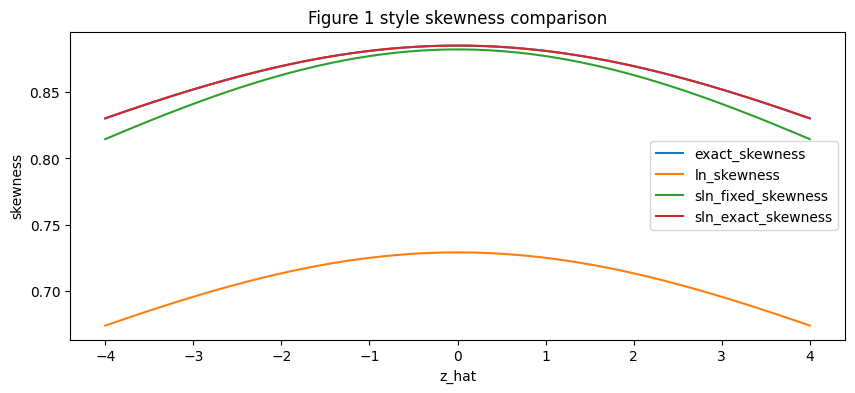

In [58]:
ax = figure1_df.plot(x='z_hat', y=['exact_skewness', 'ln_skewness', 'sln_fixed_skewness', 'sln_exact_skewness'], figsize=(10, 4), title='Figure 1 style skewness comparison')
ax.set_ylabel('skewness')


## 9. Paper Table 4

Case I. This includes the simulated rows and the available analytic comparison rows.


Fast demo note: Case I, strike grid, analytic comparison rows, and helper function are unchanged; only simulation budget is reduced.

Purpose: Case I long-maturity strike sweep. This compares the proposed simulation scheme against FDM benchmarks and analytic approximation rows.


In [ ]:
table4_df = timed(
    'Paper Table 4 demo-scale run',
    lambda: run_table4_experiment(n_paths=DEMO_N_PATHS_TABLE, n_repeats=DEMO_REPEATS_TABLE, seed0=12345),
)
table4_df[
      [
          'case',
          'model',
          'source',
          'strike_ratio',
          'step',
          'mean_price',
          'benchmark_price',
          'bias_x1e3',
          'runtime_sec_mean',
          'n_paths',
          'n_repeats',
      ]
  ]

Paper Table 4 demo-scale run: 0.67 sec


,case,model,source,strike_ratio,step,mean_price,benchmark_price,bias_x1e3,runtime_sec_mean,n_paths,n_repeats
0,Case I,Our method,simulated,0.2,1.0000,0.843697,0.84255,1.146850,0.017303,5000.0,2.0
1,Case I,Our method,simulated,0.4,1.0000,0.689820,0.68906,0.759833,0.017303,5000.0,2.0
2,Case I,Our method,simulated,0.8,1.0000,0.408061,0.40646,1.601213,0.017303,5000.0,2.0
3,Case I,Our method,simulated,1.0,1.0000,0.287044,0.28502,2.023663,0.017303,5000.0,2.0
4,Case I,Our method,simulated,1.2,1.0000,0.185382,0.18304,2.341839,0.017303,5000.0,2.0
5,Case I,Our method,simulated,1.6,1.0000,0.054523,0.05343,1.092973,0.017303,5000.0,2.0
6,Case I,Our method,simulated,2.0,1.0000,0.011540,0.01096,0.580159,0.017303,5000.0,2.0
7,Case I,Our method,simulated,0.2,0.2500,0.842841,0.84255,0.291399,0.063569,5000.0,2.0
8,Case I,Our method,simulated,0.4,0.2500,0.689929,0.68906,0.869272,0.063569,5000.0,2.0
9,Case I,Our method,simulated,0.8,0.2500,0.408747,0.40646,2.286979,0.063569,5000.0,2.0


## 10. Paper Table 5

Case II.


Fast demo note: Case II is unchanged; only simulation budget is reduced.

Purpose: Case II long-maturity strike sweep. It repeats the Table 4 style comparison under a different beta/rho parameter set.


In [47]:
table5_df = timed(
    'Paper Table 5 demo-scale run',
    lambda: run_table5_experiment(n_paths=DEMO_N_PATHS_TABLE, n_repeats=DEMO_REPEATS_TABLE, seed0=12345),
)
table5_df[
      [
          'case',
          'model',
          'source',
          'strike_ratio',
          'step',
          'mean_price',
          'benchmark_price',
          'bias_x1e3',
          'runtime_sec_mean',
          'n_paths',
          'n_repeats',
      ]
  ]


Paper Table 5 demo-scale run: 0.67 sec


,case,model,source,strike_ratio,step,mean_price,benchmark_price,bias_x1e3,runtime_sec_mean,n_paths,n_repeats
0,Case II,Our method,simulated,0.2,1.0000,0.835790,0.82886,6.930326,0.017156,5000.0,2.0
1,Case II,Our method,simulated,0.4,1.0000,0.676695,0.66959,7.105094,0.017156,5000.0,2.0
2,Case II,Our method,simulated,0.8,1.0000,0.404875,0.39772,7.155398,0.017156,5000.0,2.0
3,Case II,Our method,simulated,1.0,1.0000,0.297398,0.29118,6.217604,0.017156,5000.0,2.0
4,Case II,Our method,simulated,1.2,1.0000,0.212081,0.20690,5.181267,0.017156,5000.0,2.0
5,Case II,Our method,simulated,1.6,1.0000,0.103191,0.10018,3.011152,0.017156,5000.0,2.0
6,Case II,Our method,simulated,2.0,1.0000,0.050965,0.05014,0.824657,0.017156,5000.0,2.0
7,Case II,Our method,simulated,0.2,0.2500,0.826330,0.82886,-2.530464,0.063484,5000.0,2.0
8,Case II,Our method,simulated,0.4,0.2500,0.667205,0.66959,-2.385482,0.063484,5000.0,2.0
9,Case II,Our method,simulated,0.8,0.2500,0.396341,0.39772,-1.378646,0.063484,5000.0,2.0


## 11. Paper Table 6

Case III. This is the runtime / bias comparison against paper-reference baseline rows.


Fast demo note: Case III and paper-reference baseline rows are unchanged; only our simulation budget is reduced.

Purpose: Case III comparison with other Monte Carlo methods reported in the paper. This section emphasizes speed and bias relative to baseline schemes.


In [48]:
table6_df = timed(
    'Paper Table 6 demo-scale run',
    lambda: run_table6_experiment(n_paths=DEMO_N_PATHS_TABLE, n_repeats=DEMO_REPEATS_TABLE, seed0=12345),
)
table6_df[
      [
          'case',
          'model',
          'source',
          'strike_ratio',
          'step',
          'mean_price',
          'benchmark_price',
          'bias_x1e3',
          'runtime_sec_mean',
          'n_paths',
          'n_repeats',
      ]
  ]


Paper Table 6 demo-scale run: 0.15 sec


,case,model,source,strike_ratio,step,mean_price,benchmark_price,bias_x1e3,runtime_sec_mean,n_paths,n_repeats
0,Case III,Our method,simulated,0.4,1.000000,0.046341,0.04559,0.750629,0.001896,5000.0,2.0
1,Case III,Our method,simulated,0.8,1.000000,0.042053,0.04141,0.643195,0.001896,5000.0,2.0
2,Case III,Our method,simulated,1.0,1.000000,0.040003,0.03942,0.582879,0.001896,5000.0,2.0
3,Case III,Our method,simulated,1.2,1.000000,0.038032,0.03750,0.532340,0.001896,5000.0,2.0
4,Case III,Our method,simulated,1.6,1.000000,0.034308,0.03390,0.407755,0.001896,5000.0,2.0
5,Case III,Our method,simulated,2.0,1.000000,0.030893,0.03061,0.282671,0.001896,5000.0,2.0
6,Case III,Euler,paper_reference,0.4,0.002500,0.047190,0.04559,1.600000,4.120000,NaN,NaN
7,Case III,Euler,paper_reference,0.8,0.002500,0.042910,0.04141,1.500000,4.120000,NaN,NaN
8,Case III,Euler,paper_reference,1.0,0.002500,0.040920,0.03942,1.500000,4.120000,NaN,NaN
9,Case III,Euler,paper_reference,1.2,0.002500,0.038900,0.03750,1.400000,4.120000,NaN,NaN


## 12. Paper Table 7 / Figure 2

This section can be slow. It reproduces the convergence and runtime trade-off dataset.


Fast demo note: the convergence-study structure is unchanged, but the path ladder and benchmark budget are scaled down for a live run.

Purpose: convergence and runtime tradeoff. The full paper version uses much larger path counts; the fast demo preserves the structure with a smaller path ladder.


In [49]:
table7_df = timed(
    'Paper Table 7 demo-scale run',
    lambda: run_table7_experiment(
        n_paths_base=DEMO_TABLE7_BASE_PATHS,
        n_repeats=1,
        seed0=12345,
        benchmark_source='fdm',
        benchmark_n_paths=DEMO_TABLE7_BENCHMARK_PATHS,
        benchmark_repeats=1,
    ),
)
table7_df[
      [
          'case',
          'model',
          'source',
          'n_paths',
          'step',
          'runtime_sec_mean',
          'rms_error_x1e3',
          'benchmark_note',
      ]
  ]


Paper Table 7 demo-scale run: 4.00 sec


,case,model,source,n_paths,step,runtime_sec_mean,rms_error_x1e3,benchmark_note
0,Case IV,Our method,simulated,5000.0,1.0000,0.007561,5.696091,PDE/FDM benchmark
1,Case IV,Our method,simulated,10000.0,0.5000,0.025986,9.282697,PDE/FDM benchmark
2,Case IV,Our method,simulated,20000.0,0.2500,0.095856,5.971022,PDE/FDM benchmark
3,Case IV,Our method,simulated,40000.0,0.1250,0.384687,6.402750,PDE/FDM benchmark
4,Case IV,Our method,simulated,80000.0,0.0625,1.582501,5.815497,PDE/FDM benchmark
5,Case IV,Our method (paper reference),paper_reference,160000.0,1.0000,0.530000,3.270000,paper FDM benchmark
6,Case IV,Our method (paper reference),paper_reference,320000.0,0.5000,2.270000,1.940000,paper FDM benchmark
7,Case IV,Our method (paper reference),paper_reference,640000.0,0.2500,9.660000,1.210000,paper FDM benchmark
8,Case IV,Our method (paper reference),paper_reference,1280000.0,0.1250,41.350000,0.860000,paper FDM benchmark
9,Case IV,Our method (paper reference),paper_reference,2560000.0,0.0625,279.530000,0.590000,paper FDM benchmark


In [50]:
figure2_df = timed(
    'Paper Figure 2 demo-scale dataset',
    lambda: figure2_runtime_tradeoff(
        n_paths_base=DEMO_TABLE7_BASE_PATHS,
        n_repeats=1,
        seed0=12345,
        benchmark_source='fdm',
    ),
)


Paper Figure 2 demo-scale dataset: 4.11 sec


### Figure 2 Plot

This plot turns the Table 7 / Figure 2 dataset into the paper-style runtime versus RMS error view. The live-demo points use reduced path counts; paper-reference points, when present, are kept as reference markers.

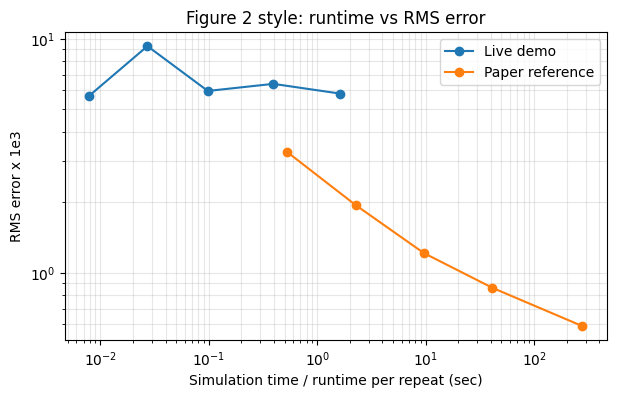

In [51]:
import matplotlib.pyplot as plt

fig2_plot_df = figure2_df.dropna(subset=['runtime_sec_mean', 'rms_error_x1e3']).copy()
fig2_plot_df['series'] = fig2_plot_df['source'].map({
    'simulated': 'Live demo',
    'paper_reference': 'Paper reference',
}).fillna(fig2_plot_df['source'])

fig, ax = plt.subplots(figsize=(7, 4))
for label, grp in fig2_plot_df.groupby('series'):
    grp = grp.sort_values('runtime_sec_mean')
    ax.plot(grp['runtime_sec_mean'], grp['rms_error_x1e3'], marker='o', label=label)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Simulation time / runtime per repeat (sec)')
ax.set_ylabel('RMS error x 1e3')
ax.set_title('Figure 2 style: runtime vs RMS error')
ax.grid(True, which='both', alpha=0.3)
ax.legend()
plt.show()

## 13. Paper Figure 3

This compares the paper scheme against the Islah approximation across maturities.


Fast demo note: the method-vs-Islah comparison is unchanged, but paths/repeats are reduced.

Purpose: direct comparison between the paper method and Islah. The key diagnostic is forward-price drift: the paper method should keep `E[F_T]` closer to `F0`.


In [52]:
figure3_df = timed(
    'Paper Figure 3 demo-scale run',
    lambda: run_figure3_experiment(
        n_paths=DEMO_FIGURE3_PATHS,
        n_repeats=1,
        seed0=12345,
        benchmark_source='mc',
        benchmark_n_paths=DEMO_FIGURE3_BENCHMARK_PATHS,
        benchmark_repeats=1,
    ),
)


Paper Figure 3 demo-scale run: 0.96 sec


In [53]:
pivot_forward = figure3_df.pivot_table(index='maturity', columns=['model', 'step'], values='forward_error')
pivot_option = figure3_df.pivot_table(index='maturity', columns=['model', 'step'], values='option_error')

display(pivot_forward)
display(pivot_option)


model        Islah           Our method          
step           0.5       1.0        0.5       1.0
maturity                                         
1.0       0.000158 -0.011993   0.010984 -0.006045
2.0       0.002297  0.006086  -0.002399 -0.001129
3.0       0.001242  0.009836  -0.010545 -0.010630
4.0      -0.016497  0.023473   0.007946  0.004993
5.0       0.003079  0.022589  -0.012798  0.017215
6.0       0.029477  0.023347  -0.001945  0.004060
7.0       0.021323  0.033888  -0.009423 -0.000420
8.0       0.006863  0.031140  -0.000095 -0.009887
9.0       0.011483  0.018783  -0.008571 -0.013029
10.0      0.010459  0.042146  -0.000839 -0.025973

model        Islah           Our method          
step           0.5       1.0        0.5       1.0
maturity                                         
1.0      -0.000506 -0.001765   0.006740 -0.000178
2.0       0.002266  0.003729   0.002670 -0.004222
3.0       0.008424 -0.000583  -0.003939 -0.006822
4.0      -0.012137  0.014160   0.005226  0.001103
5.0       0.001802  0.009262   0.001932  0.008205
6.0       0.015297  0.012746   0.003320  0.001779
7.0       0.005336  0.009220  -0.008225 -0.005404
8.0      -0.006775  0.005734  -0.006413 -0.010854
9.0       0.002212  0.010729  -0.007325 -0.013676
10.0     -0.004821  0.018272  -0.008249 -0.020240

### Figure 3 Plots

These plots turn the Figure 3 comparison dataset into the paper-style visual comparison. Panel (a) shows forward-price error, which is the martingale diagnostic. Panel (b) shows ATM option-price error.

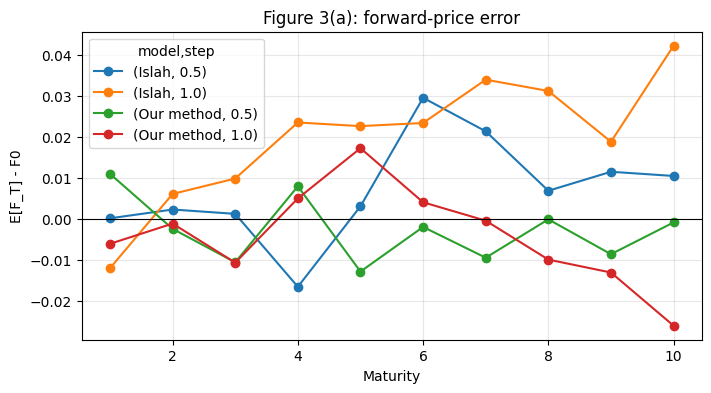

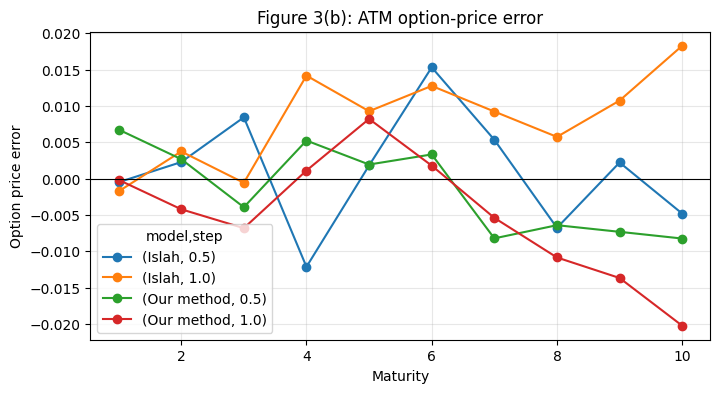

In [22]:
import matplotlib.pyplot as plt

ax = pivot_forward.plot(figsize=(8, 4), marker='o', title='Figure 3(a): forward-price error')
ax.axhline(0.0, color='black', linewidth=0.8)
ax.set_xlabel('Maturity')
ax.set_ylabel('E[F_T] - F0')
ax.grid(True, alpha=0.3)
plt.show()

ax = pivot_option.plot(figsize=(8, 4), marker='o', title='Figure 3(b): ATM option-price error')
ax.axhline(0.0, color='black', linewidth=0.8)
ax.set_xlabel('Maturity')
ax.set_ylabel('Option price error')
ax.grid(True, alpha=0.3)
plt.show()

## 14. Validation Summary

Start with quick mode. The paper-scale run is much slower.


Fast demo note: quick validation is retained. Full paper-scale validation remains commented out because it is intentionally slow.

Purpose: summarize whether the current implementation is structurally consistent with the paper. In fast demo mode this is a smoke test, not a final statistical claim.


In [ ]:
validation_quick = timed(
    'Validation quick smoke test',
    lambda: run_full_validation(quick_mode=True),
)
pd.Series({
    'table1_status': validation_quick['table1_status'],
    'table2_status': validation_quick['table2_status'],
    'overall_conclusion': validation_quick['overall_conclusion'],
    'replication_conclusion': validation_quick['replication_conclusion'],
})


In [ ]:
# Uncomment this only when you want the full validation sweep.
# This is intentionally left paper-scale and can be slow.
# validation_full = run_full_validation(quick_mode=False)
# pd.Series({
#     'table1_status': validation_full['table1_status'],
#     'table2_status': validation_full['table2_status'],
#     'overall_conclusion': validation_full['overall_conclusion'],
#     'replication_conclusion': validation_full['replication_conclusion'],
# })

runtime_df = pd.DataFrame(runtime_rows)
runtime_df.loc[len(runtime_df)] = {'section': 'Notebook elapsed so far', 'seconds': time.perf_counter() - notebook_start}
runtime_df


## 15. Optional CSV Export Helpers

Use these after running the sections you care about.

Purpose: after a live run, uncomment these lines only for the tables or figures you want to export.


In [ ]:
OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'notebook_exports'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR


In [ ]:
# Example exports. Uncomment what you need.
# table1_df.to_csv(OUTPUT_DIR / 'table1.csv', index=False)
# table2_df.to_csv(OUTPUT_DIR / 'table2.csv', index=False)
# table4_df.to_csv(OUTPUT_DIR / 'table4.csv', index=False)
# table5_df.to_csv(OUTPUT_DIR / 'table5.csv', index=False)
# table6_df.to_csv(OUTPUT_DIR / 'table6.csv', index=False)
# table7_df.to_csv(OUTPUT_DIR / 'table7.csv', index=False)
# figure1_df.to_csv(OUTPUT_DIR / 'figure1_dataset.csv', index=False)
# figure3_df.to_csv(OUTPUT_DIR / 'figure3_dataset.csv', index=False)
